# Simple Harmonic Oscillator: plain ANN vs Physics-Informed Neural Network (PINN)

**Goal.** Fit a noisy signal from a Simple Harmonic Oscillator (SHO) and forecast beyond the observed time window, comparing:

| | Plain ANN | PINN |
|---|---|---|
| Information used | Noisy data only | Noisy data **+** the governing ODE **+** initial conditions |
| Loss | $\mathcal{L} = \mathcal{L}_{data}$ | $\mathcal{L} = \mathcal{L}_{data} + \lambda_{phys}\,\mathcal{L}_{phys} + \lambda_{IC}\,\mathcal{L}_{IC}$ |

The physical system is

$$\ddot{x}(t) + \omega^2 x(t) = 0, \qquad x(t) = A\cos(\omega t + \phi)$$

**Fair comparison.** Both models share the *same* training data, test set, normalization, architecture (`SHONet`) and initial weights (same random seed). The only thing that changes is the **loss function**.

**Notebook outline**
1. Setup & helper functions
2. Experimental setup: data, test set and features (shared)
3. Model 1 — Plain ANN
4. Model 2 — PINN
5. ANN vs PINN: head-to-head comparison

## 1. Setup & helper functions

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

#### Data generation & feature engineering

In [2]:
def create_syntetic_HO_data(A, omega, phi=0.0, noise_std=None,
                            t_start=0.0, t_end=1.5, n_points=500, seed=42,
                            plot_noise_dist=True, plot_signal=True):
    """
    Generate synthetic Simple Harmonic Oscillator data x(t) = A cos(omega t + phi)
    with additive Gaussian noise.

    Parameters
    ----------
    A : float               Amplitude.
    omega : float           Angular frequency (rad/s).
    phi : float             Phase offset (rad).
    noise_std : float       Std dev of Gaussian noise (defaults to 0.3*A).
    t_start, t_end : float  Time interval.
    n_points : int          Number of time samples.
    seed : int              Random seed for reproducibility.
    plot_noise_dist : bool  If True, plot the noise (error) distribution.
    plot_signal : bool      If True, plot the clean signal and noisy data.

    Returns
    -------
    t, x_clean, x_noisy : np.ndarray
    """
    if noise_std is None:
        noise_std = 0.3 * A

    # Time vector
    t = np.linspace(t_start, t_end, n_points)

    # Clean displacement
    x_clean = A * np.cos(omega * t + phi)

    # Add Gaussian noise
    rng = np.random.default_rng(seed=seed)
    noise = rng.normal(loc=0.0, scale=noise_std, size=t.shape)
    x_noisy = x_clean + noise

    if plot_noise_dist:
        plt.figure(figsize=(7, 4))
        sns.histplot(noise, kde=True, stat="density", bins=15, color="steelblue", edgecolor="white")
        plt.xlabel("Noise value")
        plt.ylabel("Density")
        plt.title("Distribution of Gaussian Noise")
        plt.grid(alpha=0.8)
        plt.show()

    if plot_signal:
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.plot(t, x_clean, label="Clean signal", linewidth=2)
        ax.scatter(t, x_noisy, color="orange", s=15, label="Noisy data", alpha=0.7)
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Displacement")
        ax.set_title("Synthetic Simple Harmonic Oscillator Data")
        ax.legend(loc="lower right")
        ax.grid(alpha=0.8)
        plt.show()

    return t, x_clean, x_noisy

In [3]:
def create_NN_features(t, x_noisy, normalize=True):
    """
    Build (optionally normalized) column-vector tensors to train the NN.

    Parameters
    ----------
    t : np.ndarray          Time samples.
    x_noisy : np.ndarray    Noisy displacement measurements.
    normalize : bool        If True, z-score normalize t and x using their mean/std.
                            If False, use mean=0 and std=1 (i.e. data is left as is).

    Returns
    -------
    t_norm, x_norm : torch.Tensor           Features and targets, shape (N, 1).
    t_mean, t_std, x_mean, x_std : torch.Tensor
        Statistics used, needed to normalize new inputs and unnormalize predictions.
    """
    # Convert data to tensors (reshape to column vectors)
    t_tensor = torch.tensor(t, dtype=torch.float32).reshape(-1, 1)
    x_tensor = torch.tensor(x_noisy, dtype=torch.float32).reshape(-1, 1)

    if normalize:
        t_mean, t_std = t_tensor.mean(), t_tensor.std()
        x_mean, x_std = x_tensor.mean(), x_tensor.std()
    else:  # Un-normalization
        t_mean, t_std = torch.tensor(0.0), torch.tensor(1.0)
        x_mean, x_std = torch.tensor(0.0), torch.tensor(1.0)

    t_norm = (t_tensor - t_mean) / t_std
    x_norm = (x_tensor - x_mean) / x_std

    return t_norm, x_norm, t_mean, t_std, x_mean, x_std

#### Network architecture (shared by both models)

In [4]:
class SHONet(nn.Module):
    def __init__(self, hidden_sizes=(32, 64, 128, 64, 32)):
        """hidden_sizes: number of neurons (out_features) of each hidden layer, in order."""
        super().__init__()
        layers = []
        in_features = 1
        for out_features in hidden_sizes:
            layers += [nn.Linear(in_features, out_features), nn.Tanh()]
            in_features = out_features
        layers.append(nn.Linear(in_features, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

#### Inference & evaluation

In [5]:
def predict(model, t, t_mean, t_std, x_mean, x_std):
    """
    Run inference on raw times t (np.ndarray) and return predictions in physical units.
    Inputs are normalized with the TRAINING statistics and outputs are unnormalized.
    """
    model.eval()
    t_tensor = torch.tensor(t, dtype=torch.float32).reshape(-1, 1)
    t_norm = (t_tensor - t_mean) / t_std
    with torch.no_grad():
        x_pred_norm = model(t_norm)
    return (x_pred_norm * x_std + x_mean).numpy().flatten()


def compute_metrics(x_true, x_pred):
    """Regression metrics in physical units."""
    err = x_pred - x_true
    mse = np.mean(err**2)
    return {
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "MAE": np.mean(np.abs(err)),
        "R2": 1 - np.sum(err**2) / np.sum((x_true - x_true.mean())**2),
    }


def plot_fit(t, x_noisy, x_clean, x_pred, title, data_label="Noisy data", pred_label="NN prediction"):
    """Prediction vs data/ground truth (top) and residuals w.r.t. ground truth (bottom)."""
    fig, (ax, ax_res) = plt.subplots(2, 1, figsize=(16, 8), sharex=True,
                                     gridspec_kw={"height_ratios": [3, 1]})
    ax.scatter(t, x_noisy, s=15, color="orange", alpha=0.5, label=data_label)
    ax.plot(t, x_clean, color="green", linewidth=2, linestyle="--", label="True SHO")
    ax.plot(t, x_pred, color="blue", linewidth=2, alpha=0.7, label=pred_label)
    ax.set_ylabel("Displacement")
    ax.set_title(title)
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0))
    ax.grid(alpha=0.8)

    ax_res.plot(t, x_pred - x_clean, color="red", linewidth=1.5)
    ax_res.axhline(0, color="gray", linestyle=":")
    ax_res.set_xlabel("Time (s)")
    ax_res.set_ylabel("Pred - True")
    ax_res.grid(alpha=0.8)

    plt.tight_layout()
    plt.show()

#### Physics-informed components (PINN only)
- `physics_residual`: ODE residual $r(t) = \ddot{x} + \omega^2 x$, computed with autograd and corrected for normalization via the chain rule.
- `ic_loss`: penalizes deviations from $x(0) = x_0$ and $\dot{x}(0) = v_0$.
- `train_PINN`: training loop for the composite loss.

In [6]:
def physics_residual(model, t_norm, omega, t_std, x_std):
    """
    Computes x'' + omega^2 * x = 0
    correcting for the chain rule introduced by normalization.
    """
    x_norm = model(t_norm)

    # dx_norm/dt_norm via autograd
    dx_norm = torch.autograd.grad(x_norm, t_norm, grad_outputs=torch.ones_like(x_norm),
                                   create_graph=True)[0]
    d2x_norm = torch.autograd.grad(dx_norm, t_norm, grad_outputs=torch.ones_like(dx_norm),
                                    create_graph=True)[0]

    # Chain rule: since t_norm = (t - t_mean)/t_std and x_norm = (x - x_mean)/x_std,
    # d2x/dt2 = (x_std / t_std^2) * d2x_norm/dt_norm2
    d2x_dt2 = (x_std / t_std**2) * d2x_norm
    x_real = x_norm * x_std + x_mean

    residual = d2x_dt2 + (omega**2) * x_real
    return residual

def ic_loss(model, t_mean, t_std, x_mean, x_std, x0, v0):
    """
    Enforces x(0) = x0 and x'(0) = v0
    """
    t0 = torch.tensor([[0.0]], requires_grad=True)
    t0_norm = (t0 - t_mean) / t_std

    x0_pred_norm = model(t0_norm)
    x0_pred_real = x0_pred_norm * x_std + x_mean

    dx0_norm = torch.autograd.grad(x0_pred_norm, t0_norm,
                                    grad_outputs=torch.ones_like(x0_pred_norm),
                                    create_graph=True)[0]
    # chain rule: dx/dt = (x_std/t_std) * dx_norm/dt_norm
    v0_pred_real = (x_std / t_std) * dx0_norm

    loss_x0 = (x0_pred_real - x0)**2
    loss_v0 = (v0_pred_real - v0)**2

    return loss_x0.squeeze() + loss_v0.squeeze()

In [7]:
def train_PINN(model, t_data_norm, x_data_norm, t_colloc_norm,
               omega, t_mean, t_std, x_mean, x_std, x0, v0,
               lambda_physics=5e-4, lambda_ic=5e-4, lr=5e-5, n_epochs=int(2e4), print_every=500):
    """
    Train a PINN with loss = data loss + lambda_physics * physics loss + lambda_ic * IC loss.

    Returns
    -------
    losses : dict of lists  'data', 'physics', 'ic', 'total' loss per epoch
             (physics and IC are stored unweighted).
    """
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    losses = {"data": [], "physics": [], "ic": [], "total": []}

    model.train()
    for epoch in range(n_epochs):
        optimizer.zero_grad()

        # Data loss (normalized space)
        x_pred_norm = model(t_data_norm)
        loss_data = criterion(x_pred_norm, x_data_norm)

        # Physics loss (ODE residual on collocation points)
        residual = physics_residual(model, t_colloc_norm, omega, t_std, x_std)
        loss_physics = torch.mean(residual**2)

        # Initial condition loss
        loss_ic = ic_loss(model, t_mean, t_std, x_mean, x_std, x0, v0)

        loss = loss_data + lambda_physics * loss_physics + lambda_ic * loss_ic
        loss.backward()
        optimizer.step()

        losses["data"].append(loss_data.item())
        losses["physics"].append(loss_physics.item())
        losses["ic"].append(loss_ic.item())
        losses["total"].append(loss.item())

        if (epoch + 1) % print_every == 0:
            print(f"Epoch {epoch+1}/{n_epochs} | Total: {loss.item():.5f} | "
                  f"Data: {loss_data.item():.5f} | Physics: {loss_physics.item():.5f} | "
                  f"IC: {loss_ic.item():.5f}")

    return losses

## 2. Experimental setup (shared by both models)

- **Training data:** noisy observations over one period $T = 2\pi/\omega$.
- **Test data:** *new* noisy observations on times **after** the training window (forecasting), with independent noise (different seed).

In [8]:
# ---- SHO parameters ----
A = 32             # amplitude
omega = 6.0        # angular frequency (rad/s)
phi = 0.0          # phase offset
noise_std = 0.3*A  # std dev of Gaussian noise
T = 2*np.pi/omega  # period (s)

# ---- Training window (observed data) ----
t_start, t_end, n_points = 0, T, 400

# ---- Test window (forecasting beyond the training data) ----
period_factor = 0.5  # length of the test window as a fraction of the period
t_test_start, t_test_end, n_test_points = t_end, t_end + T * period_factor, 100

# ---- Shared model settings (identical for ANN and PINN) ----
hidden_sizes = (16, 32, 16, 8)
SEED = 0  # same seed -> both models start from the same initial weights

#### Training data

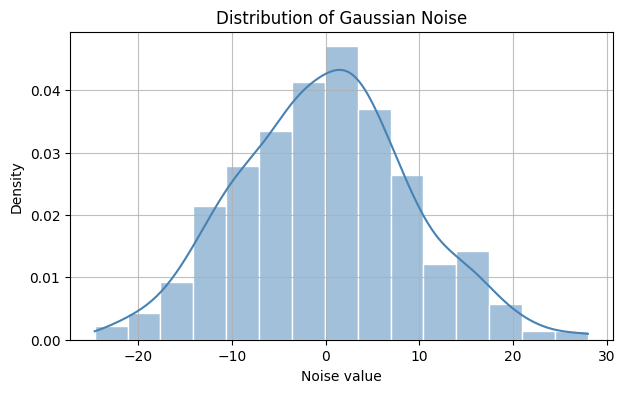

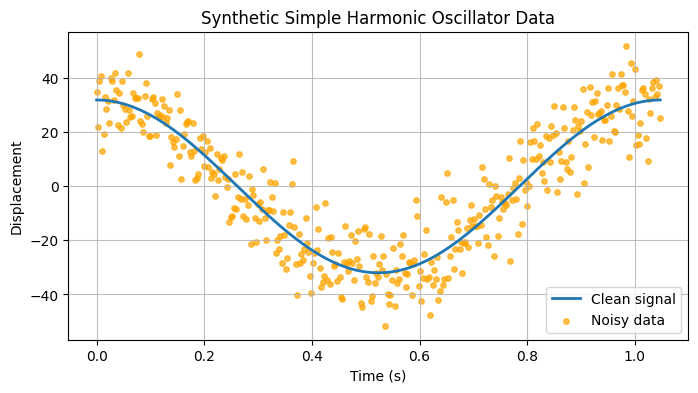

In [9]:
t, x_clean, x_noisy = create_syntetic_HO_data(
    A, omega, phi, noise_std, t_start, t_end, n_points,
    plot_noise_dist=True, plot_signal=True,
)

#### Test data

In [10]:
t_test, x_test_clean, x_test_noisy = create_syntetic_HO_data(
    A, omega, phi, noise_std, t_test_start, t_test_end, n_test_points,
    seed=123,  # different seed -> independent noise from the training set
    plot_noise_dist=False, plot_signal=False,
)

# Dense grid over training + test windows, used for plots
t_full = np.linspace(t_start, t_test_end, 1000)
x_full_true = A * np.cos(omega * t_full + phi)

#### Features (same normalization for both models)

In [11]:
t_norm, x_norm, t_mean, t_std, x_mean, x_std = create_NN_features(t, x_noisy, normalize=True)

## 3. Model 1 — Plain ANN (data only)

The network only sees the noisy observations. It minimizes

$$\mathcal{L}_{ANN} = \frac{1}{N}\sum_{i=1}^{N}\left(\hat{x}(t_i) - x_i^{noisy}\right)^2$$

Nothing tells it that the signal is an oscillator, so outside the training window it has no information to rely on.

In [12]:
torch.manual_seed(SEED)
model_ann = SHONet(hidden_sizes=hidden_sizes)
print(model_ann)

SHONet(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=16, bias=True)
    (1): Tanh()
    (2): Linear(in_features=16, out_features=32, bias=True)
    (3): Tanh()
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): Tanh()
    (6): Linear(in_features=16, out_features=8, bias=True)
    (7): Tanh()
    (8): Linear(in_features=8, out_features=1, bias=True)
  )
)


#### Training

In [13]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_ann.parameters(), lr=1e-3)

n_epochs = 1500
losses_ann = []

for epoch in range(n_epochs):
    optimizer.zero_grad()
    pred = model_ann(t_norm)
    loss = criterion(pred, x_norm)   # compare in normalized space
    loss.backward()
    optimizer.step()
    losses_ann.append(loss.item())

    if (epoch + 1) % 200 == 0:
        print(f"Epoch {epoch+1}/{n_epochs}, Loss: {loss.item():.6f}")

Epoch 200/1500, Loss: 0.142326
Epoch 400/1500, Loss: 0.136866
Epoch 600/1500, Loss: 0.136142
Epoch 800/1500, Loss: 0.136009
Epoch 1000/1500, Loss: 0.135909
Epoch 1200/1500, Loss: 0.135818
Epoch 1400/1500, Loss: 0.135731


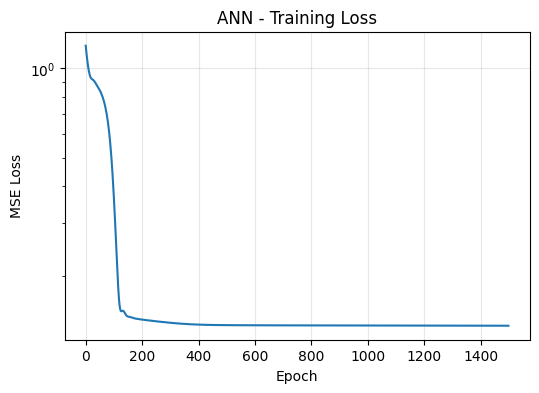

In [14]:
plt.figure(figsize=(6, 4))
plt.plot(losses_ann)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("ANN - Training Loss")
plt.yscale("log")
plt.grid(alpha=0.3)
plt.show()

#### Training set fit

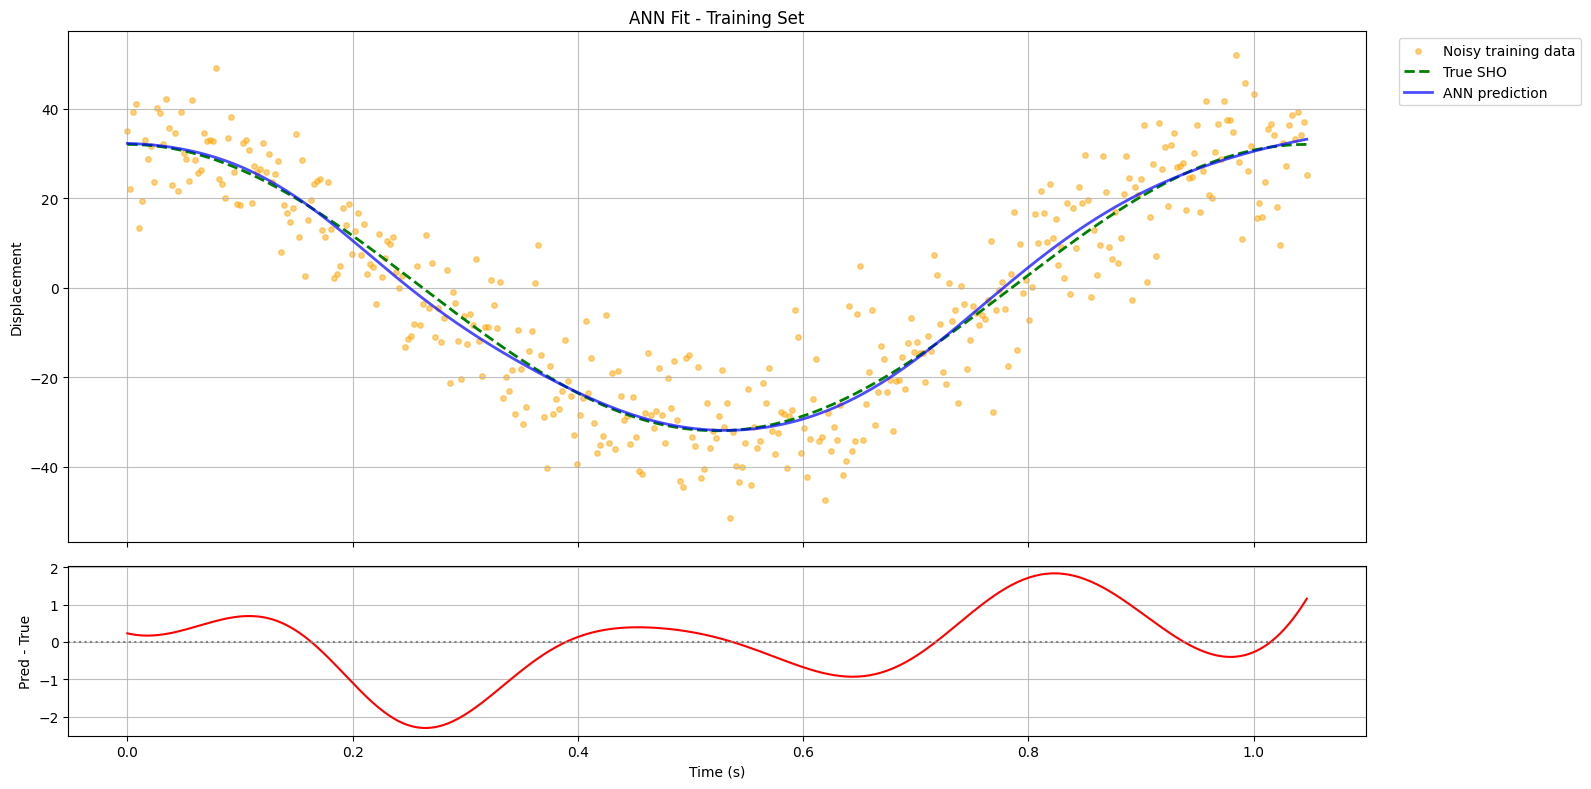

In [15]:
x_train_pred_ann = predict(model_ann, t, t_mean, t_std, x_mean, x_std)

plot_fit(t, x_noisy, x_clean, x_train_pred_ann,
         title="ANN Fit - Training Set", data_label="Noisy training data",
         pred_label="ANN prediction")

#### Test set (forecasting)

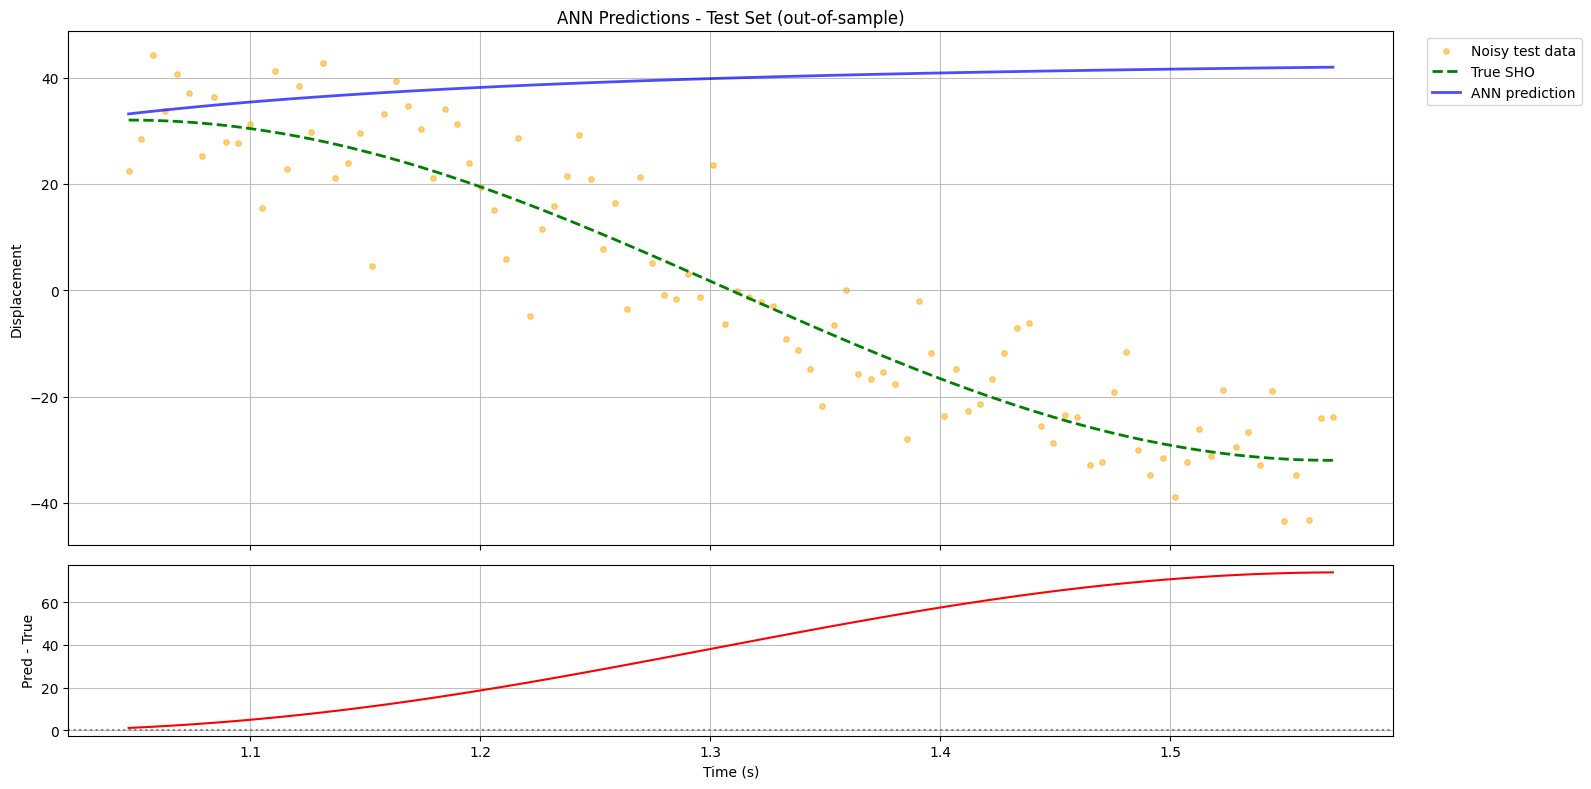

In [16]:
x_test_pred_ann = predict(model_ann, t_test, t_mean, t_std, x_mean, x_std)

plot_fit(t_test, x_test_noisy, x_test_clean, x_test_pred_ann,
         title="ANN Predictions - Test Set (out-of-sample)", data_label="Noisy test data",
         pred_label="ANN prediction")

## 4. Model 2 — Physics-Informed Neural Network

Same architecture, same data, same initial weights. The loss now also includes physics:

$$\mathcal{L}_{PINN} = \underbrace{\frac{1}{N}\sum_{i=1}^{N}\left(\hat{x}(t_i) - x_i^{noisy}\right)^2}_{\mathcal{L}_{data}}
+ \lambda_{phys}\underbrace{\frac{1}{M}\sum_{j=1}^{M}\left(\ddot{\hat{x}}(t_j) + \omega^2\hat{x}(t_j)\right)^2}_{\mathcal{L}_{phys}}
+ \lambda_{IC}\underbrace{\left[(\hat{x}(0)-x_0)^2 + (\dot{\hat{x}}(0)-v_0)^2\right]}_{\mathcal{L}_{IC}}$$

- $\mathcal{L}_{phys}$ is evaluated on **collocation points** $t_j$. These don't need measurements, so they can extend beyond the data window.
- $\mathcal{L}_{IC}$ uses the known initial state of the oscillator.

#### Collocation points & initial conditions

In [17]:
# Collocation points: dense grid where we enforce the physics
# These can extend BEYOND the data range -- this is what lets PINNs extrapolate
t_colloc = torch.linspace(t_start, t_end, 1000).reshape(-1, 1)
t_colloc_norm = ((t_colloc - t_mean) / t_std).requires_grad_(True)  # need grad for autodiff

# Initial conditions from the analytic solution
x0_true = A * np.cos(phi)           # x(0) = A cos(phi)
v0_true = -A * omega * np.sin(phi)  # x'(0) = -A*omega*sin(phi)

x0_true_t = torch.tensor(x0_true, dtype=torch.float32)
v0_true_t = torch.tensor(v0_true, dtype=torch.float32)

In [18]:
torch.manual_seed(SEED)
model_pinn = SHONet(hidden_sizes=hidden_sizes)
print(model_pinn)

SHONet(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=16, bias=True)
    (1): Tanh()
    (2): Linear(in_features=16, out_features=32, bias=True)
    (3): Tanh()
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): Tanh()
    (6): Linear(in_features=16, out_features=8, bias=True)
    (7): Tanh()
    (8): Linear(in_features=8, out_features=1, bias=True)
  )
)


#### Training

In [19]:
lambda_physics = 1e-3  # weight for physics loss relative to data loss
lambda_ic = 1e-3

losses_pinn = train_PINN(model_pinn, t_norm, x_norm, t_colloc_norm,
                         omega, t_mean, t_std, x_mean, x_std, x0_true_t, v0_true_t,
                         lambda_physics=lambda_physics, lambda_ic=lambda_ic,
                         lr=5e-5, n_epochs=int(1e5))

Epoch 500/100000 | Total: 3.19043 | Data: 0.95546 | Physics: 1362.94360 | IC: 872.03369
Epoch 1000/100000 | Total: 2.01665 | Data: 0.96196 | Physics: 81.12576 | IC: 973.56116
Epoch 1500/100000 | Total: 2.01111 | Data: 0.96279 | Physics: 68.97291 | IC: 979.35474
Epoch 2000/100000 | Total: 2.00820 | Data: 0.96324 | Physics: 65.71638 | IC: 979.24585
Epoch 2500/100000 | Total: 2.00477 | Data: 0.96377 | Physics: 61.95224 | IC: 979.04956
Epoch 3000/100000 | Total: 2.00093 | Data: 0.96437 | Physics: 57.72250 | IC: 978.83307
Epoch 3500/100000 | Total: 1.99680 | Data: 0.96502 | Physics: 53.17604 | IC: 978.60150
Epoch 4000/100000 | Total: 1.99254 | Data: 0.96567 | Physics: 48.52060 | IC: 978.34467
Epoch 4500/100000 | Total: 1.98832 | Data: 0.96628 | Physics: 44.00856 | IC: 978.03589
Epoch 5000/100000 | Total: 1.98431 | Data: 0.96675 | Physics: 39.92693 | IC: 977.62921
Epoch 5500/100000 | Total: 1.98063 | Data: 0.96700 | Physics: 36.58646 | IC: 977.04871
Epoch 6000/100000 | Total: 1.97739 | Data:

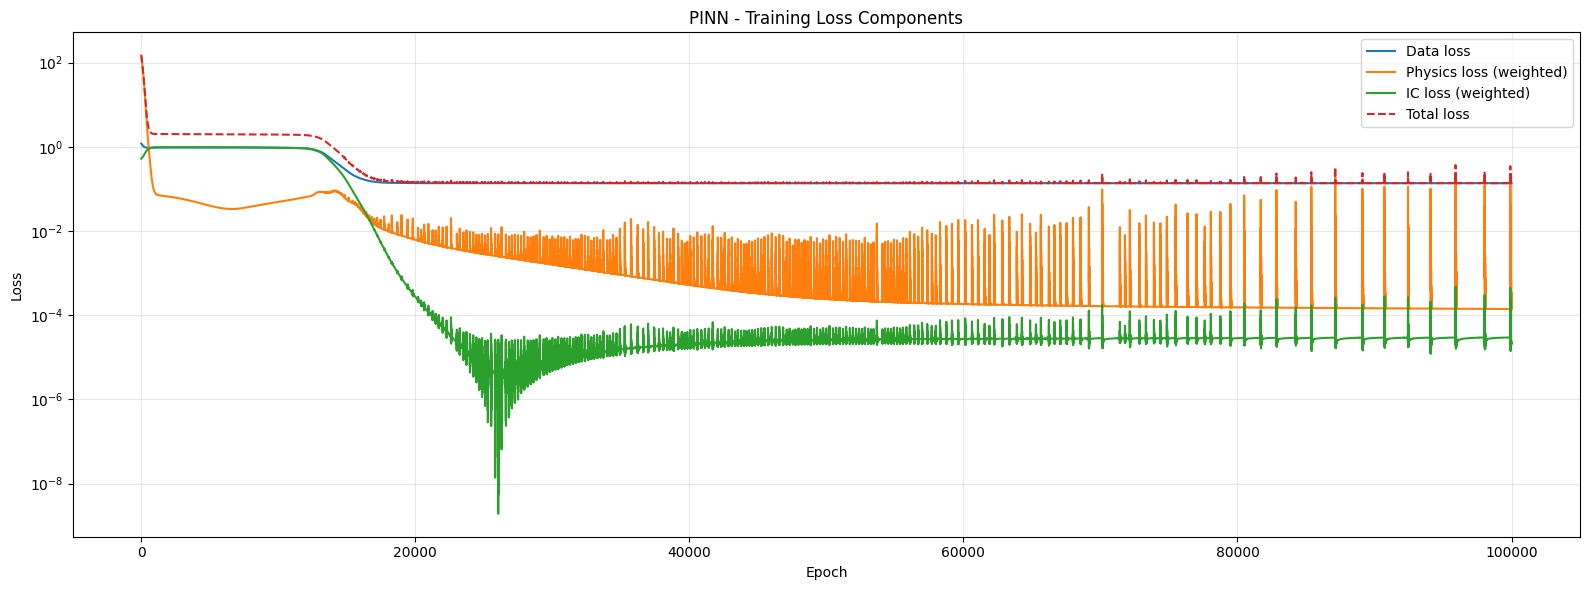

In [20]:
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(losses_pinn["data"], label="Data loss")
ax.plot(np.array(losses_pinn["physics"]) * lambda_physics, label="Physics loss (weighted)")
ax.plot(np.array(losses_pinn["ic"]) * lambda_ic, label="IC loss (weighted)")
ax.plot(losses_pinn["total"], label="Total loss", linestyle="--")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("PINN - Training Loss Components")
ax.set_yscale("log")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### Training set fit

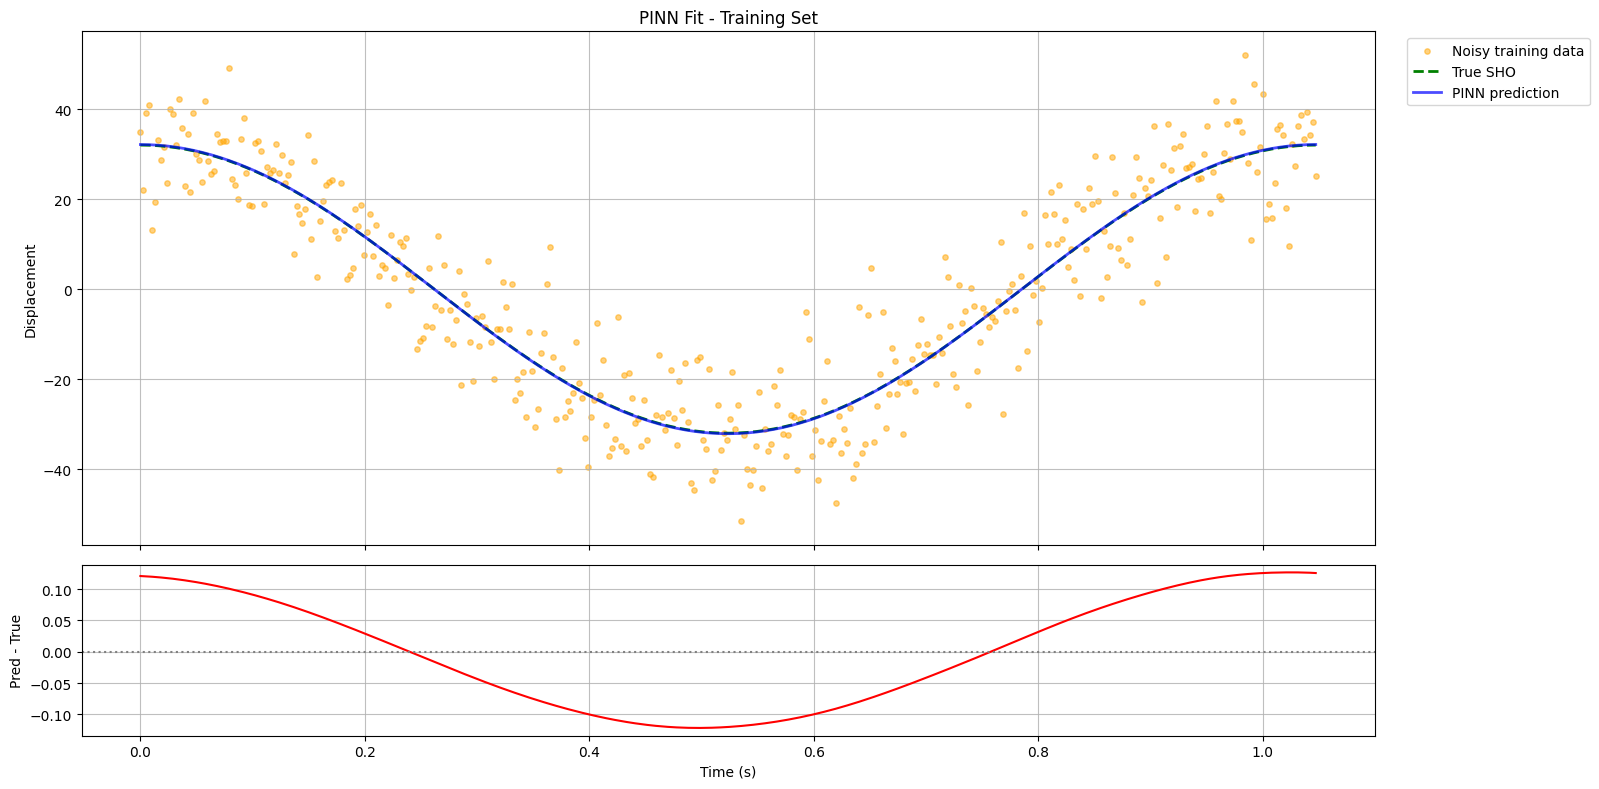

In [21]:
x_train_pred_pinn = predict(model_pinn, t, t_mean, t_std, x_mean, x_std)

plot_fit(t, x_noisy, x_clean, x_train_pred_pinn,
         title="PINN Fit - Training Set", data_label="Noisy training data",
         pred_label="PINN prediction")

#### Test set (forecasting)

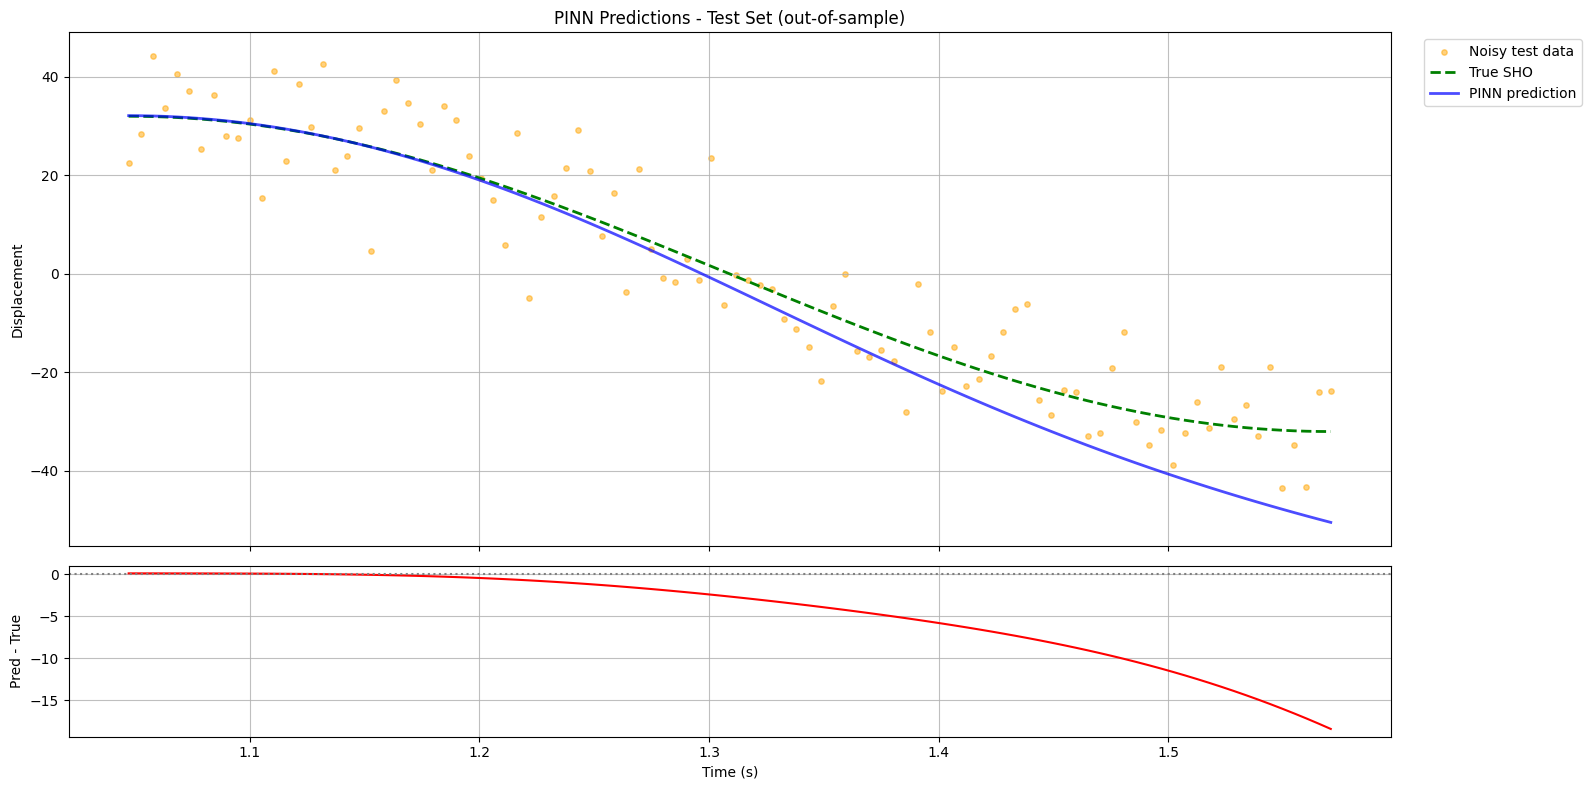

In [22]:
x_test_pred_pinn = predict(model_pinn, t_test, t_mean, t_std, x_mean, x_std)

plot_fit(t_test, x_test_noisy, x_test_clean, x_test_pred_pinn,
         title="PINN Predictions - Test Set (out-of-sample)", data_label="Noisy test data",
         pred_label="PINN prediction")

## 5. ANN vs PINN — head-to-head

Four views of the same question: *did the model learn the oscillator, or just the data?*
1. **Data loss vs noise floor:** how closely each model chases the noisy points.
2. **Predictions over training + test windows.**
3. **Prediction error over time**, against the true signal.
4. **Physical consistency:** how well each model satisfies $\ddot{x} + \omega^2 x = 0$.
5. **Metrics table.**

#### 1. Data loss vs noise floor
With independent Gaussian noise, a model that recovers the *true* signal cannot push the data MSE below the noise variance (in normalized units: $(\sigma_{noise}/\sigma_x)^2$). A data loss **below** this floor means the model is fitting the noise.

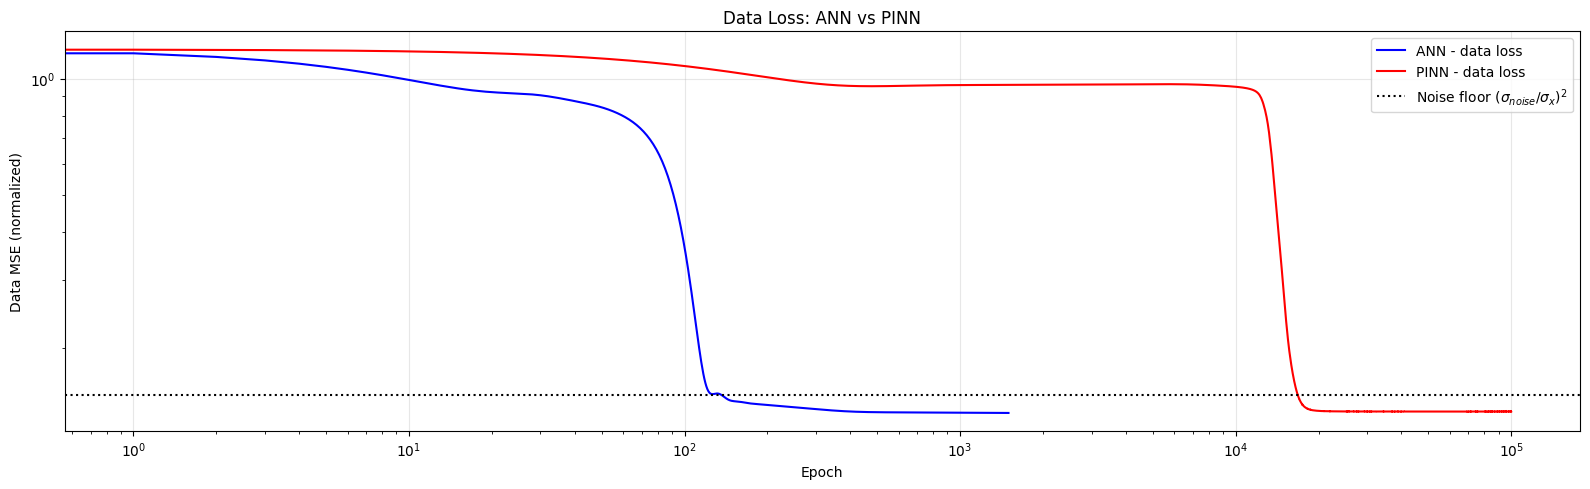

In [23]:
noise_floor = (noise_std / float(x_std))**2

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(losses_ann, color="blue", label="ANN - data loss")
ax.plot(losses_pinn["data"], color="red", label="PINN - data loss")
ax.axhline(noise_floor, color="black", linestyle=":", label="Noise floor $(\\sigma_{noise}/\\sigma_x)^2$")
ax.set_xlabel("Epoch")
ax.set_ylabel("Data MSE (normalized)")
ax.set_title("Data Loss: ANN vs PINN")
ax.set_xscale("log")
ax.set_yscale("log")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### 2. Predictions over training + test windows

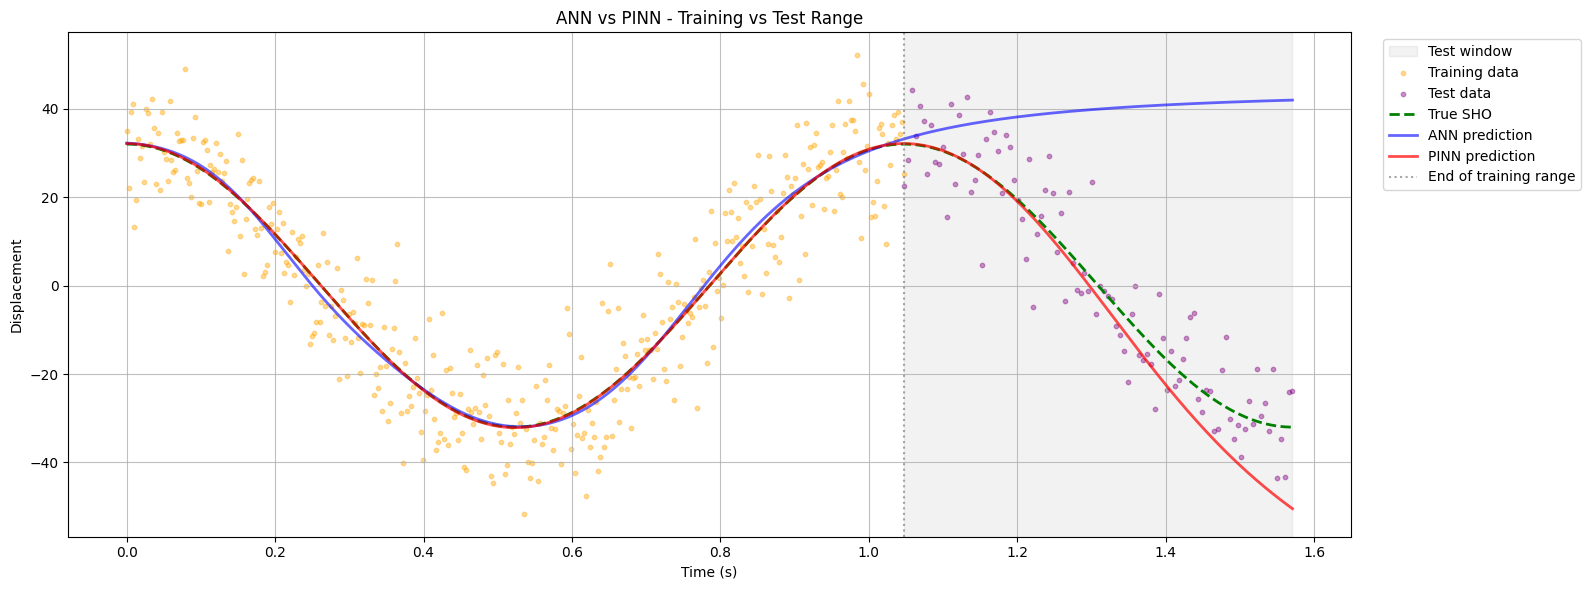

In [24]:
x_full_pred_ann = predict(model_ann, t_full, t_mean, t_std, x_mean, x_std)
x_full_pred_pinn = predict(model_pinn, t_full, t_mean, t_std, x_mean, x_std)

fig, ax = plt.subplots(figsize=(16, 6))
ax.axvspan(t_test_start, t_test_end, color="gray", alpha=0.1, label="Test window")
ax.scatter(t, x_noisy, s=10, color="orange", alpha=0.4, label="Training data")
ax.scatter(t_test, x_test_noisy, s=10, color="purple", alpha=0.4, label="Test data")
ax.plot(t_full, x_full_true, color="green", linewidth=2, linestyle="--", label="True SHO")
ax.plot(t_full, x_full_pred_ann, color="blue", linewidth=2, alpha=0.6, label="ANN prediction")
ax.plot(t_full, x_full_pred_pinn, color="red", linewidth=2, alpha=0.7, label="PINN prediction")
ax.axvline(t_end, color="gray", linestyle=":", alpha=0.7, label="End of training range")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Displacement")
ax.set_title("ANN vs PINN - Training vs Test Range")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0))
ax.grid(alpha=0.8)
plt.tight_layout()
plt.show()

#### 3. Prediction error over time (vs true signal)

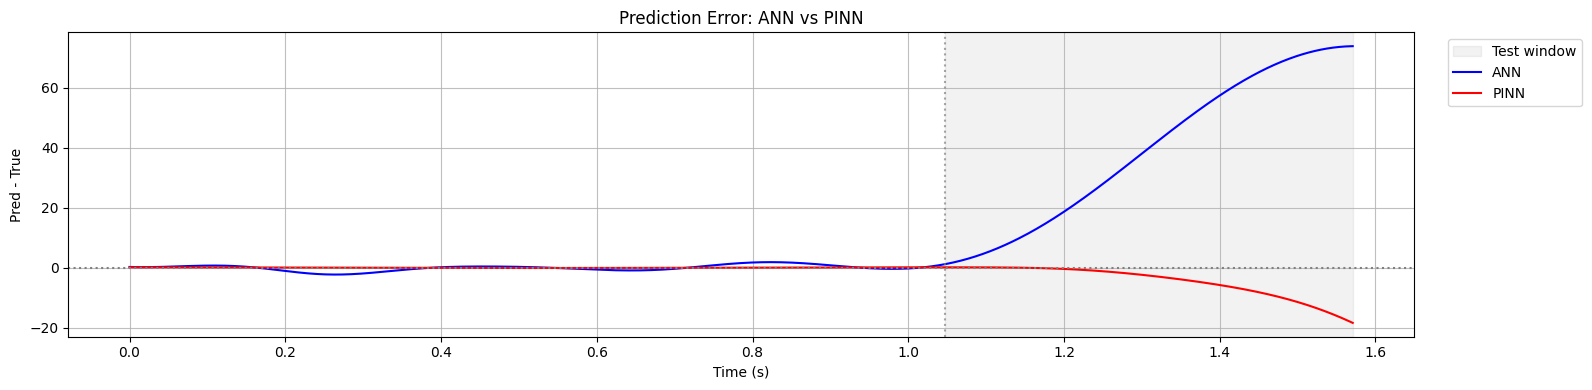

In [25]:
fig, ax = plt.subplots(figsize=(16, 4))
ax.axvspan(t_test_start, t_test_end, color="gray", alpha=0.1, label="Test window")
ax.plot(t_full, x_full_pred_ann - x_full_true, color="blue", linewidth=1.5, label="ANN")
ax.plot(t_full, x_full_pred_pinn - x_full_true, color="red", linewidth=1.5, label="PINN")
ax.axhline(0, color="gray", linestyle=":")
ax.axvline(t_end, color="gray", linestyle=":", alpha=0.7)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Pred - True")
ax.set_title("Prediction Error: ANN vs PINN")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0))
ax.grid(alpha=0.8)
plt.tight_layout()
plt.show()

#### 4. Physical consistency
Evaluate the ODE residual $r(t) = \ddot{\hat{x}} + \omega^2 \hat{x}$ of **both** trained models over the full time range. The true solution has $r(t) = 0$ everywhere. The ANN was never asked to satisfy this, so it measures how "physical" a purely data-driven fit is.

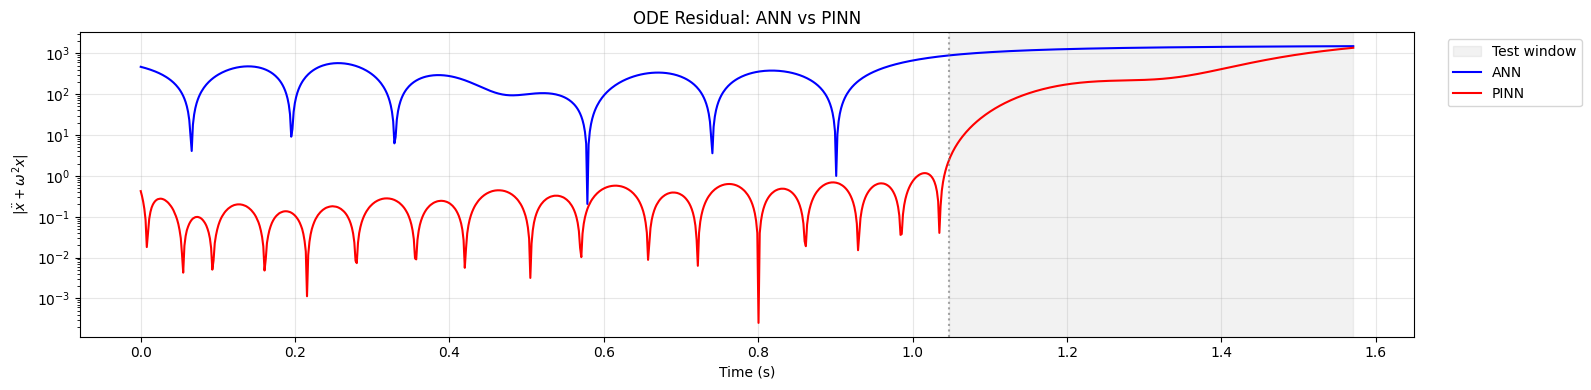

In [26]:
t_full_norm = ((torch.tensor(t_full, dtype=torch.float32).reshape(-1, 1) - t_mean) / t_std).requires_grad_(True)

res_ann = physics_residual(model_ann, t_full_norm, omega, t_std, x_std).detach().numpy().flatten()
res_pinn = physics_residual(model_pinn, t_full_norm, omega, t_std, x_std).detach().numpy().flatten()

fig, ax = plt.subplots(figsize=(16, 4))
ax.axvspan(t_test_start, t_test_end, color="gray", alpha=0.1, label="Test window")
ax.plot(t_full, np.abs(res_ann), color="blue", linewidth=1.5, label="ANN")
ax.plot(t_full, np.abs(res_pinn), color="red", linewidth=1.5, label="PINN")
ax.axvline(t_end, color="gray", linestyle=":", alpha=0.7)
ax.set_xlabel("Time (s)")
ax.set_ylabel("$|\\ddot{x} + \\omega^2 x|$")
ax.set_title("ODE Residual: ANN vs PINN")
ax.set_yscale("log")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### 5. Metrics

In [27]:
def metrics_table(x_train_pred, x_test_pred):
    return pd.DataFrame({
        "Train (vs noisy)": compute_metrics(x_noisy, x_train_pred),
        "Train (vs true)":  compute_metrics(x_clean, x_train_pred),
        "Test (vs noisy)":  compute_metrics(x_test_noisy, x_test_pred),
        "Test (vs true)":   compute_metrics(x_test_clean, x_test_pred),
    }).T

comparison = pd.concat({
    "ANN":  metrics_table(x_train_pred_ann, x_test_pred_ann),
    "PINN": metrics_table(x_train_pred_pinn, x_test_pred_pinn),
}, axis=1)

# Physical consistency (RMS of ODE residual over the full range)
physics_rms = pd.Series({"ANN": np.sqrt(np.mean(res_ann**2)),
                         "PINN": np.sqrt(np.mean(res_pinn**2))}, name="ODE residual RMS")

display(comparison.round(4))
display(physics_rms.to_frame().round(4))

ANN                                PINN           \
                        MSE     RMSE      MAE      R2       MSE     RMSE   
Train (vs noisy)    82.6263   9.0899   7.1972  0.8640   83.3315   9.1286   
Train (vs true)      0.9719   0.9859   0.7588  0.9981    0.0076   0.0874   
Test (vs noisy)   2190.0467  46.7979  39.1416 -2.6103  128.8257  11.3501   
Test (vs true)    2160.1387  46.4773  39.1777 -3.1772   48.3811   6.9557   

                                  
                     MAE      R2  
Train (vs noisy)  7.2641  0.8628  
Train (vs true)   0.0787  1.0000  
Test (vs noisy)   8.8586  0.7876  
Test (vs true)    4.6663  0.9064

,ODE residual RMS
ANN,816.844177
PINN,315.338593
